エルニーニョ現象が起こると南極付近のロス海の氷が減ることを、回帰図や相関図で確認する。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

#データ読み込み
loadfile = 'detrended_ssta_OISST.npz'
ssta_dataset = np.load(loadfile)
ssta = ssta_dataset['ssta']
lon2 = ssta_dataset['lon2']
lat2 = ssta_dataset['lat2']
y = ssta_dataset['y']
m = ssta_dataset['m']

#1990~2019年のデータのみ
ssta = ssta[:,:,(1990<=y)*(y<=2019)]
m = m[(1990<=y)*(y<=2019)]
y = y[(1990<=y)*(y<=2019)]

loadfile = 'siaa_RossSea_NSIDC.npz'
siaa_dataset = np.load(loadfile)
siaa = siaa_dataset['siaa']
y = siaa_dataset['y']
m = siaa_dataset['m']

In [2]:
#年と月を引数として渡すと、その年その月の海面水温偏差分布が描画される関数
def draw_field(field,fig_title,vmin=-6,vmax=6,vint=1):

    plt.figure()
    cm = plt.get_cmap('seismic')
    cs = plt.contourf(lon2,lat2,field,
                         cmap=cm,norm=Normalize(vmin=vmin,vmax=vmax),
                         levels=np.arange(vmin,vmax+vint,vint),extend='both')
    
    plt.colorbar(cs)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    title = fig_title
    plt.title(title)
    plt.xlim(0,360)
    plt.ylim(-90,90)
    plt.show()

#領域平均を出す関数
def aave(west,east,south,north,var=ssta):
    var = var[(west<=lon2[:,1])*(lon2[:,1]<=east),:,:]
    var = var[:,(south<=lat2[1,:])*(lat2[1,:]<=north),:]
    aave_var = np.nanmean(np.nanmean(var,0),0)
    return aave_var

In [3]:
[imt,jmt,tmt] = ssta.shape

a_ssta = np.zeros((imt,jmt))

is_land_grids_3D = (np.isnan(ssta==True))
ssta[is_land_grids_3D] = 0

#回帰図の計算
for ii in range(0,imt):
    for jj in range(0,jmt):
        a_ssta[ii,jj] = np.polyfit(siaa,ssta[ii,jj,:],1)[0]
    if(ii%30 == 0):
        print(ii)

ssta[is_land_grids_3D] = np.nan
is_land_grids_2D = np.squeeze(is_land_grids_3D[:,:,0])
a_ssta[is_land_grids_2D]=np.nan

0
30
60
90
120
150
180
210
240
270
300
330


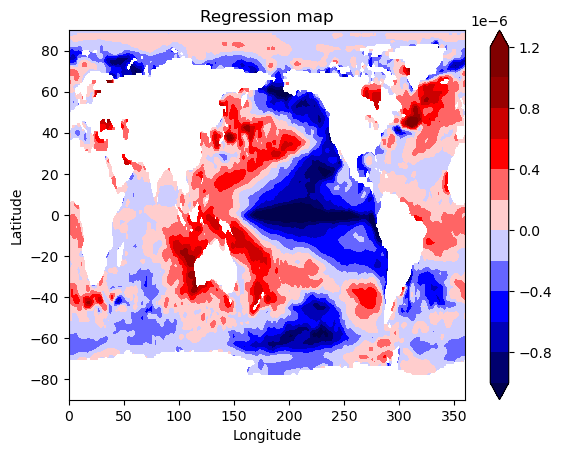

In [4]:
draw_field(a_ssta,'Regression map',-0.000001,0.000001,0.0000002)

In [5]:
r_ssta = np.zeros((imt,jmt))
ssta[is_land_grids_3D] = 0

#相関図の計算
for ii in range(0,imt):
    for jj in range(0,jmt):
        r_ssta[ii,jj] = np.corrcoef(siaa,ssta[ii,jj,:],1)[1,0]
    if(ii%30 == 0):
        print(ii)

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


0
30
60
90
120
150
180
210
240
270
300
330


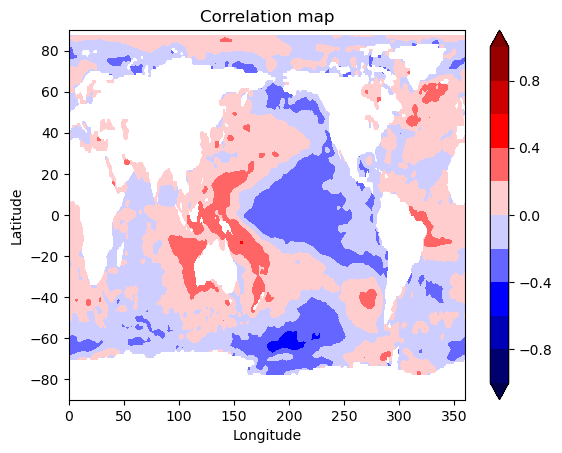

In [6]:
draw_field(r_ssta,'Correlation map',-1,1,0.2)

ペルー沖やロス海が青くなっているのは、海氷面積が大きくなったときに海面水温が下がったことを示しているから、逆に、そこの海面水温が上がる(エルニーニョ現象が起きる)と海氷面積が小さくなることもわかる。